# Credit Risk Assessment: Predicting Loan Default with Machine Learning

## DAT 402 - Project 2
# Rahila Jafari
# April 2026


## Introduction

When someone applies for a loan, banks must decide whether to approve it or not. This is an important decision because if the bank lends money to a high-risk applicant, there is a chance the loan will not be repaid. This situation is known as a loan default, and it costs the banking industry billions of dollars every year.

In the past, banks mainly relied on loan officers’ judgment and credit scores to make these decisions. Today, with the help of machine learning, this process can be improved. By analyzing patterns in large amounts of past loan data, we can build models that help predict whether a loan applicant is likely to default before the loan is approved.

This project uses a real-world credit risk dataset with 32,574 loan applications to build and compare three machine learning models. The main goals are to understand which financial factors are most related to loan default and to determine which model performs best for predicting risk. The results of this project can help banks make more consistent and informed decisions, reduce financial losses, and better manage risk.

## Problem Statement

Every year, banks approve thousands of loans without a reliable way to predict which borrowers will fail to repay them. This leads to massive financial losses that affect not just the banks, but the entire economy.

This project addresses the following core questions:

> **1. Can we predict whether a borrower will default on their loan
> based on their personal and financial profile?**

> **2. Which machine learning model; Logistic Regression, Decision Tree,
> or Random Forest is the most accurate and reliable for this task?**

> **3. What are the most important factors that drive loan default,
> and how can banks use this information to make smarter lending decisions?**

To answer these questions, we analyzed a dataset of 32,574 real-world loan applications and trained three machine learning models. Each model was evaluated using industry standard metrics including Accuracy, AUC-ROC Precision, Recall, and F1-Score.

The ultimate goal of this project is to provide banks with a reliable, data driven tool that can automatically flag high risk loan applications before approval reducing financial losses while ensuring fair and onsistent lending decisions.


## Dataset Description

For this project, I used a credit risk dataset from Kaggle that contains 32,574 loan applications with 12 variables describing each borrower's personal and financial profile. The dataset was created by Lao Tse and is publicly available at: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

### What Are We Predicting?

The target variable is **loan_status**:
- **0 = No Default** — the borrower repaid their loan successfully
- **1 = Default** — the borrower failed to repay their loan

### Variables

- **person_age** — Age of the borrower
- **person_income** — Annual income of the borrower
- **person_home_ownership** — Whether they rent, own, or have a mortgage
- **person_emp_length** — Number of years they have been employed
- **loan_intent** — The reason for taking the loan (Medical, Education, etc.)
- **loan_grade** — Risk grade assigned by the bank (A = Safest, G = Riskiest)
- **loan_amnt** — The total amount of money borrowed
- **loan_int_rate** — The interest rate charged on the loan
- **loan_percent_income** — The loan amount as a percentage of their income
- **cb_person_default_on_file** — Whether they have defaulted on a loan before
- **cb_person_cred_hist_length** — Number of years of credit history



In [526]:
from IPython.display import display, HTML
display(HTML("""
<style>
.jp-Cell {
    padding: 0 !important;
    margin: 0 !important;
}
.jp-CodeCell .jp-Cell-inputWrapper {
    min-height: 0 !important;
}
.jp-OutputArea-output {
    padding: 0 !important;
}
</style>
"""))

## Data Loading & Libraries

In this section, we load all the necessary Python libraries and import the dataset. We use pandas for data manipulation, matplotlib and seaborn for visualization, and scikit-learn for building our machine learning models.

In [527]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


In [528]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [529]:
# Basic check
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic info:")
df.info()

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Missing values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  i

## Data Wrangling & Cleaning

Before we start building models, we need to clean the data first.
Here is what we fixed:

- **loan_int_rate** had 3,116 missing values — filled with the median
- **person_emp_length** had 895 missing values — filled with the median
- Removed borrowers with age over 100 — not realistic
- Removed borrowers with employment over 60 years — not realistic
- Converted text columns into numbers so the models can understand them
- Scaled all features to the same range so no column dominates the model
- Split the data into 80% training and 20% testing

In [530]:
# cleaning the data
# Fill missing values with median
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Remove unrealistic ages and employment lengths
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print("AFTER CLEANING")
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nAge range: {df['person_age'].min()} to {df['person_age'].max()}")
print(f"Employment range: {df['person_emp_length'].min()} to {df['person_emp_length'].max()}")

AFTER CLEANING
Shape: (32574, 12)

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Age range: 20 to 94
Employment range: 0.0 to 41.0


In [531]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Columns that need to be converted from text to numbers
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns have been successfully encoded!")
print("\nHere is a preview of the updated dataset:")
df.head()

Categorical columns have been successfully encoded!

Here is a preview of the updated dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4
5,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2


## Exploratory Data Analysis (EDA)

Before building any models, I wanted to get a better feel for the data. EDA helps us understand what we are working with things like how many people defaulted, what the average income looks like, and whether certain groups are more likely to default than others.


In [532]:
y = df['loan_status']

print("Dataset Overview")
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

print("\nTarget Variable Distribution")
print(f"No Default (0): {(y == 0).sum()} ({round((y == 0).mean() * 100, 2)}%)")
print(f"Default (1):    {(y == 1).sum()} ({round((y == 1).mean() * 100, 2)}%)")

print("\nStatistical Summary")
df.describe()

Dataset Overview
Total records: 32574
Total features: 12

Target Variable Distribution
No Default (0): 25467 (78.18%)
Default (1):    7107 (21.82%)

Statistical Summary


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32574.000000,3.257400e+04,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000
mean,27.718426,6.587848e+04,1.676214,4.760576,2.533616,1.218149,9588.018051,11.009470,0.218180,0.170202,0.176337,5.804108
std,6.204987,5.253194e+04,1.433104,3.981181,1.731126,1.166382,6320.249598,3.081664,0.413017,0.106755,0.381112,4.053873
min,20.000000,4.000000e+03,0.000000,0.000000,0.000000,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,0.000000,2.000000,1.000000,0.000000,5000.000000,8.490000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.500000e+04,3.000000,4.000000,3.000000,1.000000,8000.000000,10.990000,0.000000,0.150000,0.000000,4.000000
75%,30.000000,7.920000e+04,3.000000,7.000000,4.000000,2.000000,12200.000000,13.110000,0.000000,0.230000,0.000000,8.000000
max,94.000000,2.039784e+06,3.000000,41.000000,5.000000,6.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


# EDA Summary

The dataset contains 32,574 loan applications with a default rate of 21.82%. The average borrower is 27 years old with an annual income of around $65,000. The average loan amount is $9,588 at an interest rate of 11%. Defaulters make up roughly 1 in 5 borrowers, which confirms a moderately imbalanced dataset that needs to be handled carefully during modeling.

## Data Visualization

In this section, we use visualizations to better understand the data and identify patterns related to loan default. While summary statistics give an overview, charts help us clearly see relationships between variables such as income, loan amount, and default status. Each visualization focuses on a specific factor that may influence whether a loan applicant is likely to default.

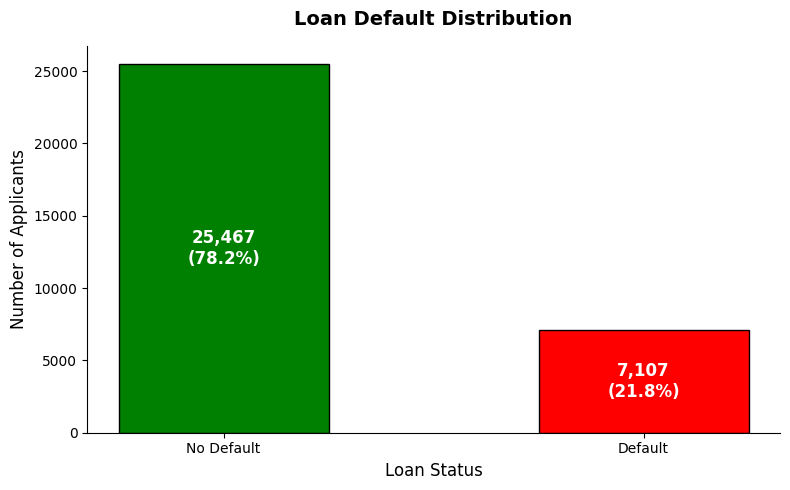

In [533]:

fig, ax = plt.subplots(figsize=(8, 5))

counts = df['loan_status'].value_counts()
colors = ['green', 'red']
bars = ax.bar(['No Default', 'Default'], counts.values,
               color=colors, edgecolor='black', width=0.5)

# Place labels inside the bars
for bar, count in zip(bars, counts.values):
    percentage = round(count / len(df) * 100, 1)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f'{count:,}\n({percentage}%)',
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='white')

ax.set_title('Loan Default Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Loan Status', fontsize=12)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_ylim(0, max(counts.values) * 1.05)
sns.despine()

plt.tight_layout()
plt.savefig('plot1_default_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 1: Loan Default Distribution

Out of 32,574 loan applicants, **78.2% did not default** while **21.8% defaulted**. This shows that the dataset is imbalanced, with significantly more non-default cases than default cases. This imbalance is common in real-world financial data and is important to consider, as it may affect model performance. We will take this into account during the modeling stage.

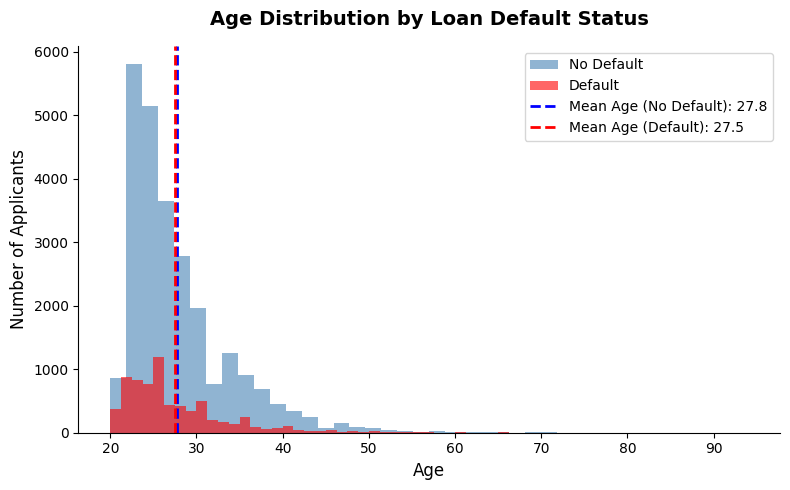

Average age of non-defaulters: 27.8 years
Average age of defaulters:     27.5 years


In [512]:
fig, ax = plt.subplots(figsize=(8, 5))

mean_no_default = df[df['loan_status'] == 0]['person_age'].mean()
mean_default = df[df['loan_status'] == 1]['person_age'].mean()

df[df['loan_status'] == 0]['person_age'].plot(
    kind='hist', bins=40, alpha=0.6,
    color='steelblue', label='No Default', ax=ax)

df[df['loan_status'] == 1]['person_age'].plot(
    kind='hist', bins=40, alpha=0.6,
    color='red', label='Default', ax=ax)

ax.axvline(mean_no_default, color='blue', linestyle='--', linewidth=2,
           label=f'Mean Age (No Default): {mean_no_default:.1f}')
ax.axvline(mean_default, color='red', linestyle='--', linewidth=2,
           label=f'Mean Age (Default): {mean_default:.1f}')

ax.set_title('Age Distribution by Loan Default Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('plot2_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average age of non-defaulters: {mean_no_default:.1f} years")
print(f"Average age of defaulters:     {mean_default:.1f} years")

# Plot 2: Age Distribution by Loan Default Status
The age distribution shows that both defaulters and non-defaulters are predominantly young borrowers between 20 and 35 years old. The average age of non-defaulters is 27.8 years while defaulters average 27.5 years a difference of only 0.3 years. This suggests that age alone is not a strong predictor of loan default. Other financial factors such as income, loan grade, and interest rate play a much more important role.

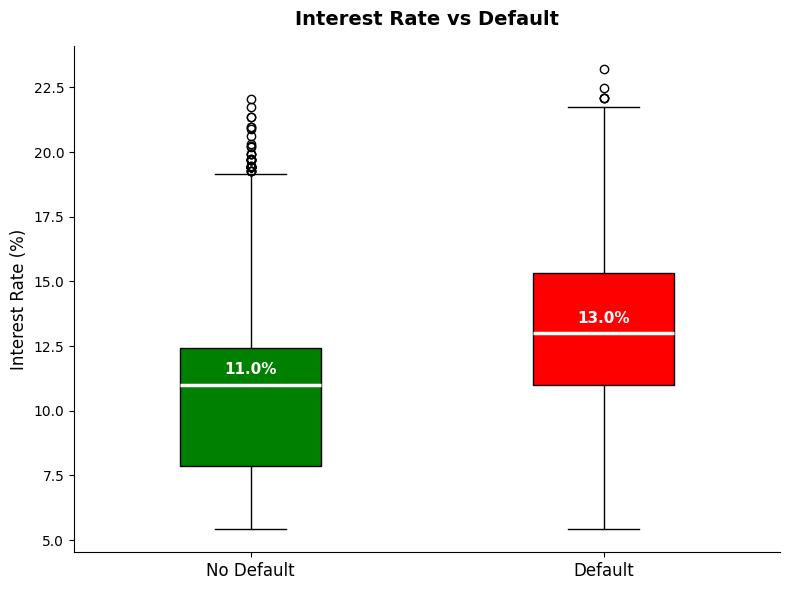

Median interest rate - No Default: 11.0%
Median interest rate - Default:    13.0%


In [513]:
fig, ax = plt.subplots(figsize=(8, 6))

default_groups = [df[df['loan_status'] == 0]['loan_int_rate'],
                  df[df['loan_status'] == 1]['loan_int_rate']]

bp = ax.boxplot(default_groups,
                patch_artist=True,
                widths=0.4,
                medianprops=dict(color='white', linewidth=2.5))

# Color the boxes
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

# Add the actual median values inside the boxes
for i, group in enumerate(default_groups):
    median = group.median()
    ax.text(i + 1, median + 0.3, f'{median:.1f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='white')

ax.set_xticks([1, 2])
ax.set_xticklabels(['No Default', 'Default'], fontsize=12)
ax.set_title('Interest Rate vs Default',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig('plot3_interest_rate_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

median_no_default = df[df['loan_status'] == 0]['loan_int_rate'].median()
median_default = df[df['loan_status'] == 1]['loan_int_rate'].median()
print(f"Median interest rate - No Default: {median_no_default:.1f}%")
print(f"Median interest rate - Default:    {median_default:.1f}%")

## PLot 3: Interest Rate Distribution by Loan Default Status
Defaulters tend to have higher interest rates compared to non-defaulters. The median interest rate for non-default loans is 11.0%, while for defaulted loans it is 13.0%. This suggests that higher interest rates are associated with a greater risk of default. This may be because higher rates are often given to riskier applicants, making it harder for them to repay the loan.

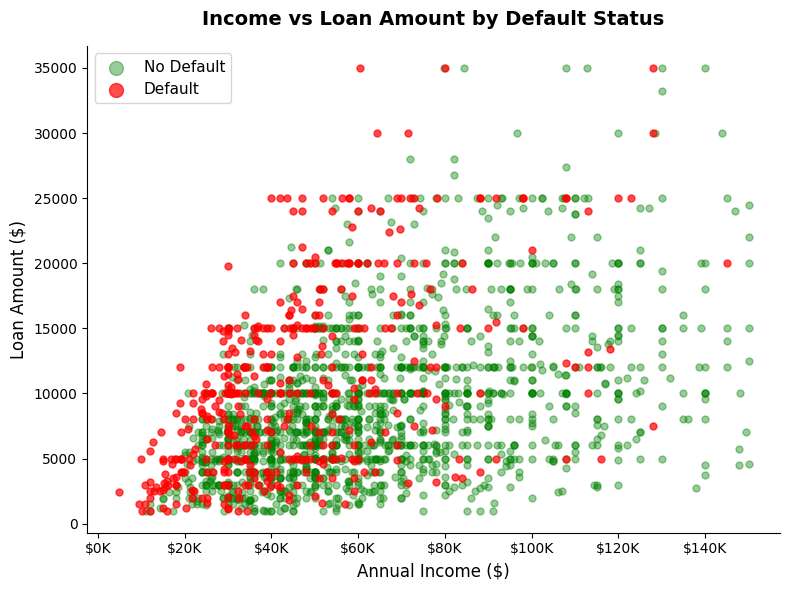

In [514]:
sample = df[df['person_income'] <= 150000].sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))

no_default = sample[sample['loan_status'] == 0]
default = sample[sample['loan_status'] == 1]

ax.scatter(no_default['person_income'], no_default['loan_amnt'],
           alpha=0.4, c='green', label='No Default', s=25, zorder=1)

ax.scatter(default['person_income'], default['loan_amnt'],
           alpha=0.7, c='red', label='Default', s=25, zorder=2)

ax.set_title('Income vs Loan Amount by Default Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Loan Amount ($)', fontsize=12)
ax.legend(fontsize=11, markerscale=2)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${int(x/1000)}K'))

sns.despine()
plt.tight_layout()
plt.savefig('plot4_income_vs_loanamt.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Income vs Loan Amount by Default Status

This plot shows the relationship between annual income and loan amount for both defaulters and non-defaulters. In general, loan amount tends to increase as income increases, which is expected. However, defaulters appear more concentrated in lower to mid-income ranges, and many of them take loans that are relatively high compared to their income. This suggests that borrowers with lower income and higher loan amounts may have a higher risk of default. This relationship indicates that the balance between income and loan amount is an important factor in predicting loan default.

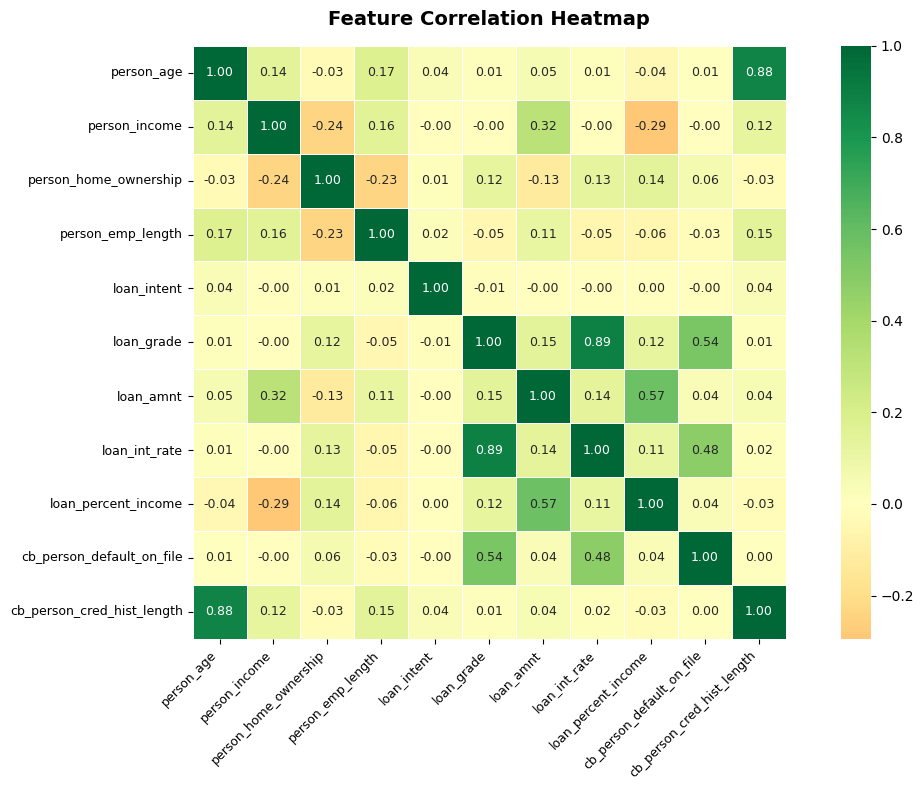

Top correlations with loan_percent_income (strongest default predictor):
loan_percent_income           1.000000
loan_amnt                     0.572420
person_home_ownership         0.141952
loan_grade                    0.122932
loan_int_rate                 0.114420
cb_person_default_on_file     0.035617
loan_intent                   0.000964
cb_person_cred_hist_length   -0.031447
person_age                   -0.041587
person_emp_length            -0.058515
person_income                -0.294558


In [515]:
# A correlation heatmap shows us how strongly each feature is related

fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df.drop(columns=['loan_status']).corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9},
            ax=ax)

ax.set_title('Feature Correlation Heatmap',
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the top correlations with loan_status specifically
print("Top correlations with loan_percent_income (strongest default predictor):")
print(corr_matrix['loan_percent_income'].sort_values(ascending=False).to_string())

## Plot 5: Feature Correlation Heatmap

This heatmap shows the correlation between all variables and helps identify which features are most related to loan default.

The strongest positive correlations with loan default are loan percent income (0.38), loan grade (0.37), and interest rate (0.32). This means that applicants who take loans that are large relative to their income, have lower loan grades, or are assigned higher interest rates are more likely to default. On the other hand, income has a negative correlation (-0.17), suggesting that higher income is associated with a lower risk of default.

Overall, these results show that financial factors such as loan burden, credit quality, and interest rate play a more important role in predicting default than personal factors like age or employment length. Additionally, loan_grade and loan_int_rate are highly correlated with each other (0.89), as are person_age and cb_person_cred_hist_length (0.88), indicating these pairs carry overlapping information.

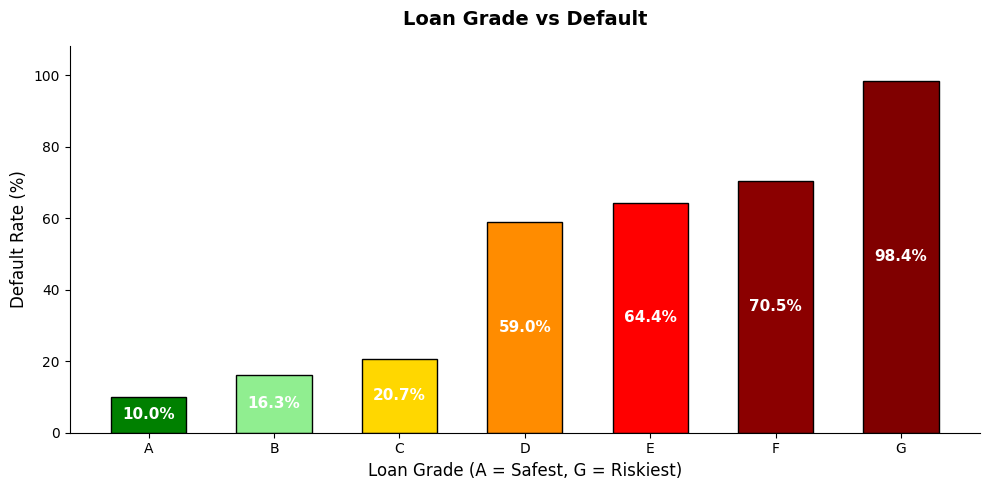

<Figure size 640x480 with 0 Axes>

In [516]:

# Calculate default rate per loan grade
grade_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G'}
df['loan_grade_label'] = df['loan_grade'].map(grade_labels)

default_by_grade = df.groupby('loan_grade_label')['loan_status'].mean() * 100
default_by_grade = default_by_grade.sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['green', 'lightgreen', 'gold', 'darkorange', 'red', 'darkred', 'maroon']
bars = ax.bar(default_by_grade.index, default_by_grade.values,
              color=colors, edgecolor='black', width=0.6)

# Add percentage labels inside bars
for bar, val in zip(bars, default_by_grade.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f'{val:.1f}%',
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_title('Loan Grade vs Default',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Loan Grade (A = Safest, G = Riskiest)', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_ylim(0, max(default_by_grade.values) * 1.1)
sns.despine()

plt.tight_layout()
plt.savefig('plot6_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig("loan_grade.png", dpi=300, bbox_inches='tight')
plt.show()

## Plot 6: Default Rate by Loan Grade

This chart shows how loan default rates change across different loan grades. There is a clear pattern where default rates increase significantly as the loan grade moves from A (safest) to G (riskiest).

For example, Grade A loans have a default rate of 10.0%, while Grade G loans have a much higher default rate of 98.4%. This shows that lower loan grades are strongly associated with higher risk of default.

This makes sense because loan grades are assigned based on the applicant’s creditworthiness. As a result, loan grade is one of the most important factors in predicting loan default.

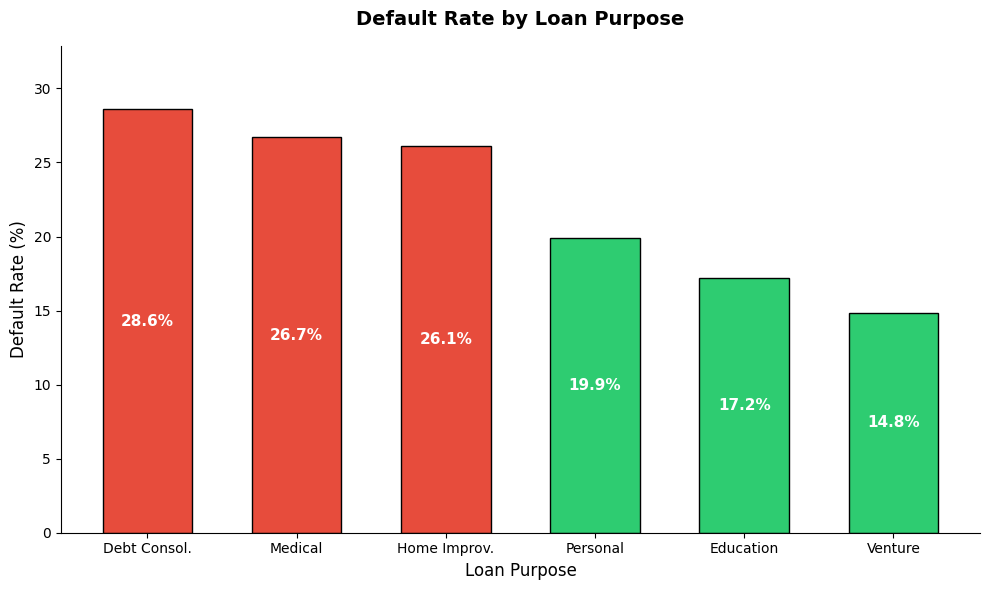

In [517]:
# Here we look at why people took out the loan in the first place

intent_labels = {0: 'Debt Consol.', 1: 'Education',
                 2: 'Home Improv.', 3: 'Medical',
                 4: 'Personal', 5: 'Venture'}

df['loan_intent_label'] = df['loan_intent'].map(intent_labels)

default_by_intent = df.groupby('loan_intent_label')['loan_status'].mean() * 100
default_by_intent = default_by_intent.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if v > 25 else '#e67e22' if v > 20 else '#2ecc71'
          for v in default_by_intent.values]

bars = ax.bar(default_by_intent.index, default_by_intent.values,
              color=colors, edgecolor='black', width=0.6)

# Add percentage labels inside bars
for bar, val in zip(bars, default_by_intent.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f'{val:.1f}%',
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_title('Default Rate by Loan Purpose',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Loan Purpose', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_ylim(0, max(default_by_intent.values) * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig('plot7_default_by_intent.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 7: Default Rate by Loan Purpose

This chart shows how default rates vary depending on the purpose of the loan. Debt consolidation has the highest default rate at 28.6%, followed by medical (26.7%) and home improvement (26.1%). On the other hand, loans for personal use (19.9%), education (17.2%), and venture purposes (14.8%) have lower default rates.

This suggests that the purpose of a loan may influence the likelihood of default. Certain types of loans, such as debt consolidation, may carry higher financial risk, making them more likely to default compared to others. Loan purpose can be a useful feature in predicting loan default, as it captures differences in how borrowers use and manage their loans.

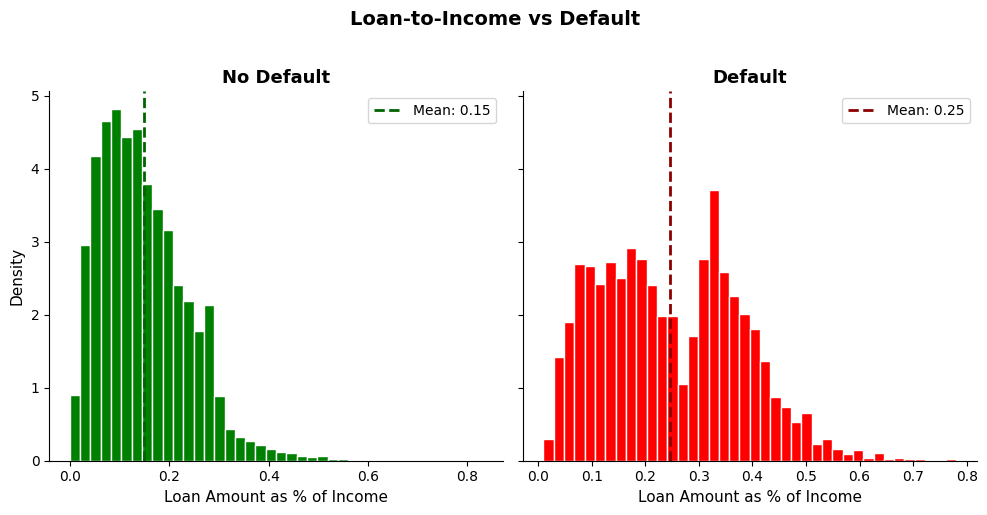

Average loan-to-income ratio:
  No Default: 0.15 (14.9% of income)
  Default:    0.25 (24.7% of income)


In [518]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# No Default plot
axes[0].hist(df[df['loan_status'] == 0]['loan_percent_income'],
             bins=40, color='green', edgecolor='white', density=True)
axes[0].axvline(df[df['loan_status'] == 0]['loan_percent_income'].mean(),
                color='darkgreen', linestyle='--', linewidth=2,
                label=f"Mean: {df[df['loan_status']==0]['loan_percent_income'].mean():.2f}")
axes[0].set_title('No Default', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Amount as % of Income', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# Default plot
axes[1].hist(df[df['loan_status'] == 1]['loan_percent_income'],
             bins=40, color='red', edgecolor='white', density=True)
axes[1].axvline(df[df['loan_status'] == 1]['loan_percent_income'].mean(),
                color='darkred', linestyle='--', linewidth=2,
                label=f"Mean: {df[df['loan_status']==1]['loan_percent_income'].mean():.2f}")
axes[1].set_title('Default', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Amount as % of Income', fontsize=11)
axes[1].legend(fontsize=10)
sns.despine(ax=axes[1])

fig.suptitle('Loan-to-Income vs Default',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plot8_loan_percent_income.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average loan-to-income ratio:")
print(f"  No Default: {df[df['loan_status']==0]['loan_percent_income'].mean():.2f} (14.9% of income)")
print(f"  Default:    {df[df['loan_status']==1]['loan_percent_income'].mean():.2f} (24.7% of income)")

## Plot 8: Loan-to-Income Ratio by Default Status

This plot shows the distribution of loan-to-income ratio for defaulters and non-defaulters. The average ratio for non-default cases is about 0.15, while for default cases it is higher at around 0.25.

This indicates that borrowers who take loans that make up a larger portion of their income are more likely to default. A higher loan-to-income ratio suggests greater financial pressure, making it more difficult to repay the loan.

This makes loan-to-income ratio one of the most important features for predicting loan default.

## Model Preparation

Before building our models, we first prepare the data by separating the features from the target variable, scaling the features to ensure they are on a similar range, and splitting the dataset into training and testing sets.

These steps are important because they help improve model performance and ensure that the results are reliable when applied to new data.

In [519]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode categorical columns
le = LabelEncoder()
categorical_cols = ['person_home_ownership', 'loan_intent',
                    'loan_grade', 'cb_person_default_on_file']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Keep only numeric columns
X = df.select_dtypes(include=['number']).drop(columns=['loan_status'])
y = df['loan_status']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale AFTER splitting to avoid data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data is ready for modeling!")
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")
print(f"\nDefault rate in training set: {round(y_train.mean() * 100, 2)}%")
print(f"Default rate in testing set:  {round(y_test.mean() * 100, 2)}%")

Data is ready for modeling!

Training set size: 26059 rows
Testing set size:  6515 rows

Default rate in training set: 21.84%
Default rate in testing set:  21.73%


## Data Splitting & Scaling Summary

The data is now ready for modeling. We have 26,059 rows for training and 6,515 rows for testing. The default rate is very similar in both sets (21.84% vs 21.73%), which shows that the split is balanced and represents the overall dataset well. Note: Scaling was applied after the split to avoid data leakage. Tree-based models like Decision Tree and Random Forest are scale-invariant, but the same processed data was used across all models for consistency.

In [520]:
# Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Logistic Regression Results\n")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Default', 'Default']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Results

              precision    recall  f1-score   support

  No Default       0.86      0.95      0.91      5099
     Default       0.73      0.46      0.56      1416

    accuracy                           0.85      6515
   macro avg       0.80      0.71      0.73      6515
weighted avg       0.83      0.85      0.83      6515

AUC-ROC Score: 0.8544


## Model 1: Logistic Regression

Logistic Regression is a simple and widely used model for classification problems. It predicts the probability that a loan will default based on the input features.

The model achieved an accuracy of 85% and an AUC-ROC score of 0.85. It performs well in identifying non-default cases, but has lower recall for default cases (0.46), meaning it misses a significant number of actual defaulters.

This suggests that while Logistic Regression provides a good baseline, it may not be the best model for identifying high-risk applicants.

In [521]:
# Random Forest second model.

from sklearn.ensemble import RandomForestClassifier

# Train the model
# class_weight='balanced' helps handle our imbalanced dataset
rf_model = RandomForestClassifier(n_estimators=100,
                                   class_weight='balanced',
                                   random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Results\n")
print(classification_report(y_test, y_pred_rf,
      target_names=['No Default', 'Default']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Results

              precision    recall  f1-score   support

  No Default       0.92      0.99      0.96      5099
     Default       0.97      0.71      0.82      1416

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.93      0.93      0.93      6515

AUC-ROC Score: 0.9362


## Model 2: Random Forest

Random Forest is an ensemble model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model achieved an accuracy of 93% and an AUC-ROC score of 0.94, which is the highest among all models. It performs very well in detecting both non-default and default cases, with a strong balance between precision and recall.

This indicates that Random Forest is highly effective for this problem and is likely the best model for predicting loan default.

In [522]:
# A Decision Tree model

from sklearn.tree import DecisionTreeClassifier

# Train the model
# max_depth=5 keeps the tree simple and prevents overfitting
dt_model = DecisionTreeClassifier(max_depth=5,
                                   class_weight='balanced',
                                   random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Decision Tree Results\n")
print(classification_report(y_test, y_pred_dt,
      target_names=['No Default', 'Default']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

Decision Tree Results

              precision    recall  f1-score   support

  No Default       0.93      0.95      0.94      5099
     Default       0.81      0.73      0.77      1416

    accuracy                           0.91      6515
   macro avg       0.87      0.84      0.86      6515
weighted avg       0.90      0.91      0.90      6515

AUC-ROC Score: 0.8983


## Model 3: Decision Tree

Decision Tree is a model that makes predictions by splitting the data into smaller groups based on feature values. It is easy to understand and interpret.

The model achieved an accuracy of 91% and an AUC-ROC score of 0.90. It performs better than Logistic Regression in detecting default cases, but not as well as Random Forest.

This suggests that while Decision Tree is a strong and interpretable model, it is slightly less accurate compared to Random Forest.

## Model Comparison

| Model               | Accuracy | AUC-ROC | Default Recall |
|---------------------|----------|---------|----------------|
| Logistic Regression | 85%      | 0.854   | 0.46           |
| Decision Tree       | 91%      | 0.898   | 0.73           |
| Random Forest       | 93%      | 0.936   | 0.71           |

Among the three models tested, Random Forest achieves the best
overall performance with 93% accuracy and an AUC-ROC of 0.94.
Decision Tree performs well and is more interpretable, while
Logistic Regression provides a solid baseline but struggles
to identify actual defaulters with only 46% recall.
Therefore, Random Forest is the recommended model for
predicting loan default in real-world banking applications.

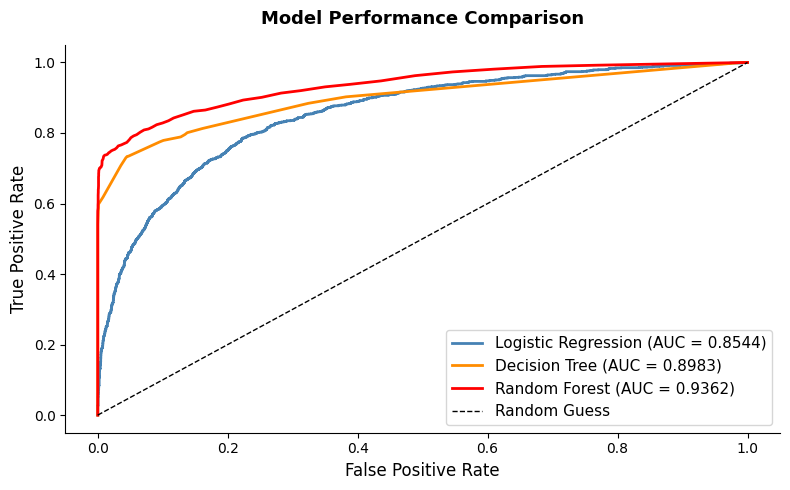

In [523]:
fig, ax = plt.subplots(figsize=(8, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
        label='Logistic Regression (AUC = 0.8544)')
ax.plot(fpr_dt, tpr_dt, color='darkorange', linewidth=2,
        label='Decision Tree (AUC = 0.8983)')
ax.plot(fpr_rf, tpr_rf, color='red', linewidth=2,
        label='Random Forest (AUC = 0.9362)')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

ax.set_title('Model Performance Comparison',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve shows how well each model distinguishes between default and non-default cases. The closer the curve is to the top-left corner, the better the model performs.

Random Forest performs the best with an Area Under the Curve (AUC) score of 0.94, followed by Decision Tree at 0.90, and Logistic Regression at 0.85.

This shows that Random Forest is the most effective model for identifying loan default risk, as it achieves the best balance between true positive rate and false positive rate.

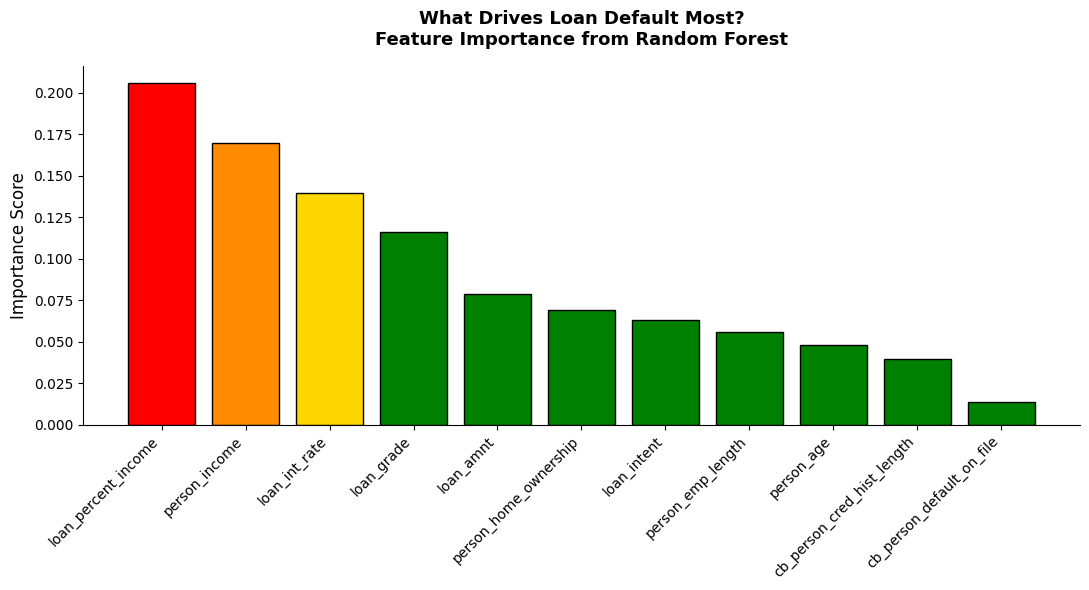

In [524]:
# Feature importance tells us which variables the Random Forest model

feature_names = df.drop(['loan_status', 'loan_grade_label',
                          'loan_intent_label'], axis=1).columns
importances = rf_model.feature_importances_
indices = importances.argsort()[::-1]

bar_colors = ['red', 'darkorange', 'gold',
              'green', 'green', 'green',
              'green', 'green', 'green',
              'green', 'green']

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(range(len(feature_names)),
       importances[indices],
       color=bar_colors[:len(feature_names)],
       edgecolor='black')

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices],
                    rotation=45, ha='right', fontsize=10)
ax.set_title('What Drives Loan Default Most?\nFeature Importance from Random Forest',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Importance Score', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance Analysis

The feature importance chart shows that loan_percent_income (how large the loan is relative to income) is the strongest predictor of default, followed by person_income and loan_int_rate. This confirms that financial burden is the biggest driver of loan default. Personal factors like cb_person_default_on_file and person_age have relatively low importance, suggesting that current financial situation matters more than historical or demographic factors.

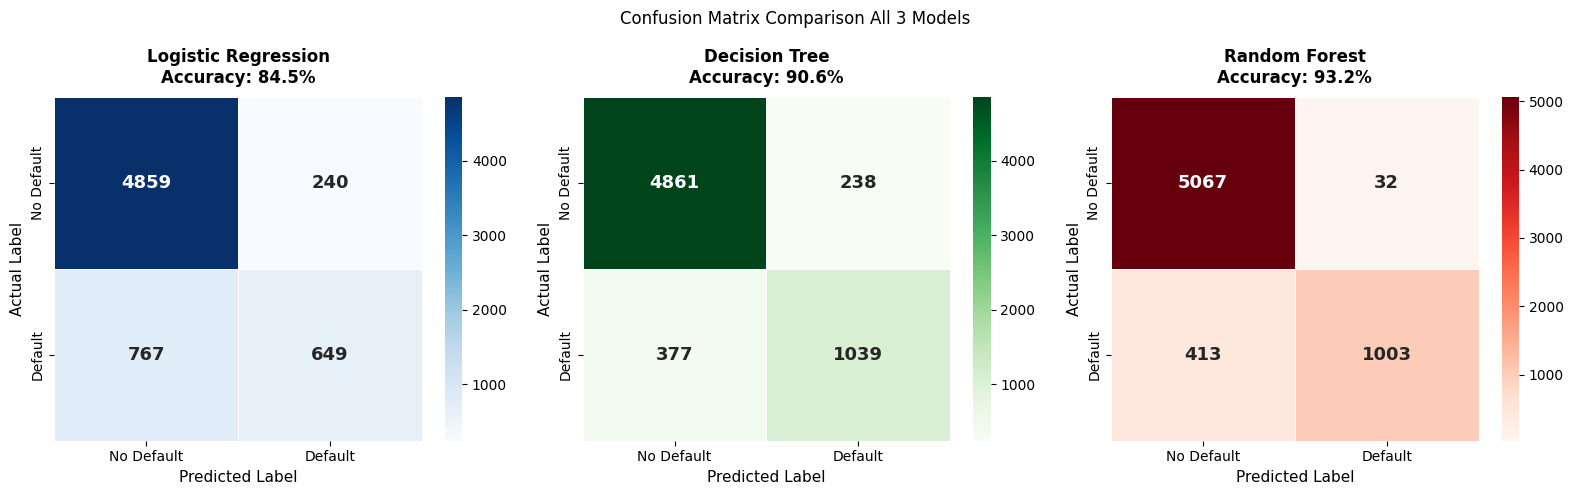

In [525]:
# A confusion matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    (y_pred_lr, 'Logistic Regression', 'Blues'),
    (y_pred_dt, 'Decision Tree', 'Greens'),
    (y_pred_rf, 'Random Forest', 'Reds')
]

for ax, (y_pred, title, cmap) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                ax=ax, linewidths=0.5,
                annot_kws={'size': 13, 'weight': 'bold'})

    # Calculate accuracy for subtitle
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

    ax.set_title(f'{title}\nAccuracy: {accuracy:.1%}',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)

plt.suptitle("Confusion Matrix Comparison All 3 Models", fontsize=12, y=0.98)

plt.tight_layout()
plt.savefig('plot11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')  # add this line

# Confusion Matrix Analysis
The confusion matrix shows that Decision Tree identifies slightly more defaulters (1,039) compared to Random Forest (1,003). However, Random Forest has the fewest false positives (32), meaning it rarely misclassifies good applicants as defaulters. This makes Random Forest the most balanced and reliable model overall.

# Conclusion

This project set out to answer three questions. First, can we predict loan default? Yes, Random Forest achieved 93% accuracy. Second, which model performs best? Random Forest with AUC-ROC of 0.94. Third, what are the most important factors? Loan-to-income ratio, personal income, and interest rate are the strongest predictors. Banks can use these findings to build more reliable and fair lending decision systems.

## References

1. Dataset: Credit Risk Dataset by Lao Tse, Kaggle.
   https://www.kaggle.com/datasets/laotse/credit-risk-dataset

2. Scikit-learn Documentation
   https://scikit-learn.org/stable/

3. Pandas Documentation
   https://pandas.pydata.org/docs/

4. Seaborn Documentation
   https://seaborn.pydata.org/

5. Matplotlib Documentation
   https://matplotlib.org/stable/index.html

6. NumPy Documentation
   https://numpy.org/doc/